In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

data_dir = Path.cwd() / "data"

training_data = pd.read_csv(data_dir / 'Train.csv')
testing_data = pd.read_csv(data_dir / 'Test.csv')

training_data.head()
training_data.describe()

,label,VH_01,VV_01,blue_01,green_01,nir_01,nira_01,re1_01,re2_01,re3_01,...,blue_12,green_12,nir_12,nira_12,re1_12,re2_12,re3_12,red_12,swir1_12,swir2_12
count,1821.000000,1821.000000,1821.000000,1821.000000,1821.000000,1821.000000,1821.000000,1821.000000,1821.000000,1821.000000,...,1821.000000,1821.000000,1821.000000,1821.000000,1821.000000,1821.000000,1821.000000,1821.000000,1821.000000,1821.000000
mean,0.403624,-25.379836,-15.136799,1651.551345,1845.806150,2317.796266,2281.221856,2072.400329,2166.834157,2239.166392,...,1601.294893,1821.759473,2303.502471,2285.164195,2045.037342,2175.002746,2237.421746,1782.470071,2249.512356,1910.365184
std,0.490759,5.586461,5.703961,274.479438,353.859045,869.923999,870.483060,462.457760,729.486832,797.647072,...,226.208186,293.915050,962.816153,964.082881,394.771895,808.934218,895.571444,317.300419,854.570513,652.673962
min,0.000000,-48.143182,-31.912804,1070.000000,1094.000000,1011.000000,1005.000000,1038.000000,1004.000000,1012.000000,...,1054.000000,1134.000000,1023.000000,1063.000000,1080.000000,1034.000000,1064.000000,1061.000000,1048.000000,1040.000000
25%,0.000000,-29.510694,-20.761611,1454.000000,1613.000000,1475.000000,1382.000000,1737.000000,1518.000000,1517.000000,...,1433.000000,1611.000000,1466.000000,1405.000000,1773.000000,1530.000000,1525.000000,1571.000000,1218.000000,1159.000000
50%,0.000000,-23.945252,-13.290349,1627.000000,1815.000000,2333.000000,2326.000000,2067.000000,2147.000000,2221.000000,...,1579.000000,1798.000000,2251.000000,2275.000000,2037.000000,2106.000000,2166.000000,1777.000000,2509.000000,1994.000000
75%,1.000000,-21.090626,-10.872466,1814.000000,2081.000000,2897.000000,2851.000000,2377.000000,2678.000000,2766.000000,...,1746.000000,2019.000000,2734.000000,2743.000000,2296.000000,2527.000000,2613.000000,1969.000000,2938.000000,2443.000000
max,1.000000,-10.404720,6.227268,3070.000000,3788.000000,6722.000000,6528.000000,3865.000000,5518.000000,6369.000000,...,3073.000000,3589.000000,7351.000000,7020.000000,3652.000000,6201.000000,6945.000000,3869.000000,4505.000000,3975.000000


Compare missing values between train and test

In [18]:
train_clean = training_data.replace(-9999, np.nan)
test_clean = testing_data.replace(-9999, np.nan)

train_missing = train_clean.isna().mean().rename('train_missing')
test_missing = test_clean.isna().mean().rename('test_missing')

missing_compare = pd.concat([train_missing, test_missing], axis=1)
missing_compare['gap'] = missing_compare['test_missing'] - missing_compare['train_missing']
print(missing_compare.sort_values('gap', ascending=False).head(20))
print(training_data['label'].value_counts(normalize=True))



          train_missing  test_missing       gap
green_01            0.0      0.875728  0.875728
swir1_01            0.0      0.875728  0.875728
blue_01             0.0      0.875728  0.875728
nira_01             0.0      0.875728  0.875728
nir_01              0.0      0.875728  0.875728
re1_01              0.0      0.875728  0.875728
re2_01              0.0      0.875728  0.875728
red_01              0.0      0.875728  0.875728
re3_01              0.0      0.875728  0.875728
swir2_01            0.0      0.875728  0.875728
VV_01               0.0      0.874757  0.874757
VH_01               0.0      0.874757  0.874757
nir_12              0.0      0.872816  0.872816
green_12            0.0      0.872816  0.872816
blue_12             0.0      0.872816  0.872816
VV_12               0.0      0.872816  0.872816
VH_12               0.0      0.872816  0.872816
swir2_12            0.0      0.872816  0.872816
swir1_12            0.0      0.872816  0.872816
red_12              0.0      0.872816  0

Missing values for month 1 and 12 for SAR and Optical meaning that these are not cloud cover issues rather missing/corrupted data

Missing data across months

In [21]:
import re

def month_of(col):
    m = re.search(r'_(\d{2})$', col)
    return m.group(1) if m else None

test_missing_df = test_missing.reset_index()
test_missing_df.columns = ['col', 'missing_rate']
test_missing_df['month'] = test_missing_df['col'].apply(month_of)

non_month_cols = [c for c in test_clean.columns if month_of(c) is None]
print("Non-month columns:", non_month_cols)

# Filter them out before grouping
test_missing_df = test_missing_df[test_missing_df['month'].notna()]

monthly_missing = test_missing_df.groupby('month')['missing_rate'].mean().sort_index()
print(monthly_missing)

# Contiguity check, excluding non-month columns
month_cols = sorted(set(test_missing_df['month']))

def months_present(row):
    present = []
    for m in month_cols:
        cols_m = [c for c in test_clean.columns if c.endswith(f'_{m}')]
        if row[cols_m].notna().any():
            present.append(m)
    return present

sample_pattern = test_clean.sample(10, random_state=1).apply(months_present, axis=1)
for idx, months in sample_pattern.items():
    print(idx, months)

Non-month columns: ['ID']
month
01    0.875566
02    0.778317
03    0.623786
04    0.496926
05    0.407605
06    0.419903
07    0.360032
08    0.413107
09    0.495631
10    0.766828
11    0.751294
12    0.872816
Name: missing_rate, dtype: float64
339 ['06', '07', '08', '09', '10']
244 ['04', '05', '06', '07']
882 ['04', '05', '06', '07', '08']
567 ['04', '05', '06', '07', '08']
923 ['07', '08', '09', '10']
358 ['03', '04', '05', '06', '07']
576 ['01', '02', '03', '04']
27 ['05', '06', '07', '08', '09']
994 ['08', '09', '10', '11', '12']
563 ['07', '08', '09', '10', '11']


Individual rows have contiguous blocks of 4–5 available months, but that block shifts around the calendar one location has Jun–Oct, another has Apr–Jul, another Jan–Apr, another Aug–Dec.
each test location was captured by a satellite pass covering a contiguous ~4-6 month acquisition window, and not a fixed test period but a rolling one.

For each band[VH, VV, blue, green, nir, nira, re1, re2, re3, red, swir1, swir2], we compute across the 12 monthly columns: nanmedian, nanstd, nanmin, nanmax, and also count (to see how many months were available)

In [23]:
bands = ['VH','VV','blue','green','nir','nira','re1','re2','re3','red','swir1','swir2']

def aggregate_bands(df, bands):
    out = pd.DataFrame(index=df.index)
    for b in bands:
        cols = [c for c in df.columns if c.startswith(b + '_')]
        vals = df[cols].values
        out[f'{b}_median'] = np.nanmedian(vals, axis=1)
        out[f'{b}_mean']   = np.nanmean(vals, axis=1)
        out[f'{b}_std']    = np.nanstd(vals, axis=1)
        out[f'{b}_min']    = np.nanmin(vals, axis=1)
        out[f'{b}_max']    = np.nanmax(vals, axis=1)
        out[f'{b}_count']  = np.sum(~np.isnan(vals), axis=1)
    return out

train_agg = aggregate_bands(train_clean, bands)
test_agg  = aggregate_bands(test_clean, bands)

train_agg['label'] = training_data['label'].values
test_agg['ID'] = testing_data['ID'].values

print(train_agg.shape, test_agg.shape)
test_agg.head()

(1821, 73) (1030, 73)


,VH_median,VH_mean,VH_std,VH_min,VH_max,VH_count,VV_median,VV_mean,VV_std,VV_min,...,swir1_min,swir1_max,swir1_count,swir2_median,swir2_mean,swir2_std,swir2_min,swir2_max,swir2_count,ID
0,-25.988535,-25.949544,0.744749,-27.256925,-24.901358,6,-6.345066,-5.276530,2.530675,-8.115721,...,1146.0,2199.0,6,1200.0,1290.500000,226.132520,1124.0,1776.0,6,ID_TS_NEW_SBZAYD5I
1,-28.704658,-28.684986,3.550809,-34.017096,-24.062675,6,-20.761848,-19.831858,3.014673,-22.539108,...,1261.0,3032.0,6,1577.0,1653.666667,333.810159,1232.0,2246.0,6,ID_TS_NEW_7SPRN3PB
2,-33.184640,-33.217796,1.791433,-35.650460,-30.900465,5,-22.316904,-23.007887,1.582004,-26.127551,...,1035.0,1626.0,5,1323.0,1268.600000,161.469006,1039.0,1505.0,5,ID_TS_NEW_LZOWPHLC
3,-30.441812,-30.376228,1.391238,-32.052381,-28.519093,5,-23.380426,-23.402791,0.702932,-24.298487,...,1081.0,1777.0,5,1251.0,1330.800000,253.493511,1062.0,1676.0,5,ID_TS_NEW_DN6TUF64
4,-20.328471,-19.887382,1.786789,-22.176431,-16.867207,6,-12.491700,-12.487371,0.706690,-13.317730,...,1938.0,3093.0,5,2045.0,2263.400000,509.066440,1572.0,2966.0,5,ID_TS_NEW_95N82M49


Misleading to the model: if count is high; predict whatever training's more common pattern was

NDWI = (green − nir) / (green + nir):   water detector
MNDWI = (green − swir1) / (green + swir1): Pond structures
NDVI = (nir − red) / (nir + red):vegetation
VH/VV ratio:  radar-based water indicator

In [24]:
def compute_monthly_indices(df):
    idx_df = pd.DataFrame(index=df.index)
    for m in [f'{i:02d}' for i in range(1, 13)]:
        green = df[f'green_{m}']
        nir   = df[f'nir_{m}']
        swir1 = df[f'swir1_{m}']
        red   = df[f'red_{m}']
        vh    = df[f'VH_{m}']
        vv    = df[f'VV_{m}']

        idx_df[f'ndwi_{m}']  = (green - nir) / (green + nir)
        idx_df[f'mndwi_{m}'] = (green - swir1) / (green + swir1)
        idx_df[f'ndvi_{m}']  = (nir - red) / (nir + red)
        idx_df[f'vhvv_{m}']  = vh - vv  # dB difference
    return idx_df

train_idx_monthly = compute_monthly_indices(train_clean)
test_idx_monthly  = compute_monthly_indices(test_clean)

# Aggregate the indices the same way as bands
def aggregate_indices(idx_df, idx_names):
    out = pd.DataFrame(index=idx_df.index)
    for name in idx_names:
        cols = [c for c in idx_df.columns if c.startswith(name + '_')]
        vals = idx_df[cols].values
        out[f'{name}_median'] = np.nanmedian(vals, axis=1)
        out[f'{name}_mean']   = np.nanmean(vals, axis=1)
        out[f'{name}_std']    = np.nanstd(vals, axis=1)
        out[f'{name}_min']    = np.nanmin(vals, axis=1)
        out[f'{name}_max']    = np.nanmax(vals, axis=1)
    return out

idx_names = ['ndwi', 'mndwi', 'ndvi', 'vhvv']
train_idx_agg = aggregate_indices(train_idx_monthly, idx_names)
test_idx_agg  = aggregate_indices(test_idx_monthly, idx_names)

# Combine with band aggregates
train_final = pd.concat([train_agg.drop(columns='label'), train_idx_agg], axis=1)
train_final['label'] = train_agg['label'].values

test_final = pd.concat([test_agg.drop(columns='ID'), test_idx_agg], axis=1)
test_final['ID'] = test_agg['ID'].values

print(train_final.shape, test_final.shape)

(1821, 93) (1030, 93)


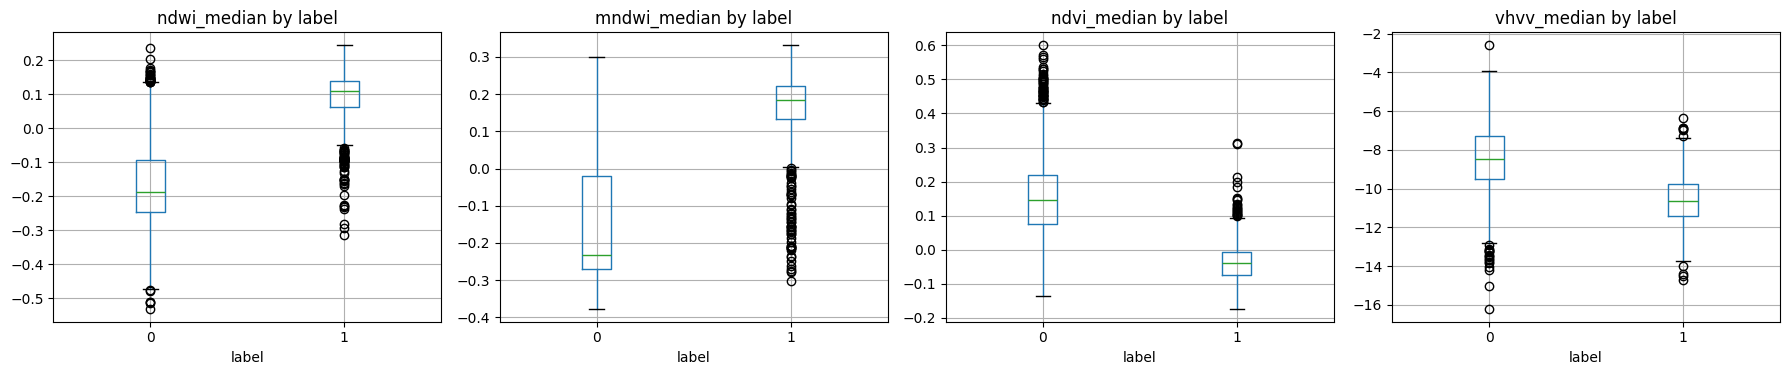

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, name in zip(axes, idx_names):
    train_final.boxplot(column=f'{name}_median', by='label', ax=ax)
    ax.set_title(f'{name}_median by label')
plt.suptitle('')
plt.tight_layout()
plt.show()

Train the model on the Training set and test it on a subset of the same

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, classification_report

import lightgbm as lgb

X = train_final.drop(columns='label')
y = train_final['label']

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = lgb.LGBMClassifier(n_estimators=500, random_state=42, verbose=-1)
model.fit(X_tr, y_tr)

val_probs = model.predict_proba(X_val)[:, 1]
val_preds = model.predict(X_val)

print("AUC:", roc_auc_score(y_val, val_probs))
print("F1:", f1_score(y_val, val_preds))
print(classification_report(y_val, val_preds))

Masking the training data:
## pick a random contiguous block of months (say, 4-6 out of 12) and set every column belonging to the excluded months to NaN, simulating "this location just doesn't have satellite coverage for these months.

The Train.csv remaining 80% of the validation set

In [29]:
import random

def simulate_test_missingness(raw_df, bands, seed=0):
    """
    For each row, randomly pick a contiguous window of 4-6 months
    (mimicking test's observed pattern) and mask out all other months.
    """
    rng = random.Random(seed)
    months = [f'{i:02d}' for i in range(1, 13)]
    masked = raw_df.copy()
    
    for idx in masked.index:
        window_len = rng.randint(4, 6)
        start = rng.randint(0, 12 - window_len)
        keep_months = months[start:start + window_len]
        drop_months = [m for m in months if m not in keep_months]
        
        cols_to_mask = [c for c in masked.columns 
                         if any(c.endswith(f'_{m}') for m in drop_months)]
        masked.loc[idx, cols_to_mask] = np.nan
    
    return masked

# Get the raw (pre-aggregation) rows corresponding to our validation split
val_idx = X_val.index
raw_val = train_clean.loc[val_idx].copy()

# Simulate test-like missingness on validation rows
raw_val_masked = simulate_test_missingness(raw_val, bands, seed=42)

# Re-run the SAME aggregation + index pipeline on the masked validation data
val_band_agg = aggregate_bands(raw_val_masked, bands)
val_idx_monthly = compute_monthly_indices(raw_val_masked)
val_idx_agg = aggregate_indices(val_idx_monthly, idx_names)

X_val_realistic = pd.concat([val_band_agg, val_idx_agg], axis=1)
X_val_realistic = X_val_realistic[X.columns]  # ensure same column order as training

# Score the SAME trained model on this harder, realistic validation set
val_probs_realistic = model.predict_proba(X_val_realistic)[:, 1]
val_preds_realistic = model.predict(X_val_realistic)

print("Realistic AUC:", roc_auc_score(y_val, val_probs_realistic))
print("Realistic F1:", f1_score(y_val, val_preds_realistic))
print(classification_report(y_val, val_preds_realistic))

Realistic AUC: 0.980465580727704
Realistic F1: 0.8814814814814815
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       218
           1       0.97      0.81      0.88       147

    accuracy                           0.91       365
   macro avg       0.93      0.90      0.91       365
weighted avg       0.92      0.91      0.91       365



Conclusion:A model trained on a perfect set of months fails when the validation is sampled randomly and used to validate it.

Train the model on masked data(missing for some months)

In [30]:
raw_tr = train_clean.loc[X_tr.index].copy()
raw_tr_masked = simulate_test_missingness(raw_tr, bands, seed=1)

tr_band_agg = aggregate_bands(raw_tr_masked, bands)
tr_idx_monthly = compute_monthly_indices(raw_tr_masked)
tr_idx_agg = aggregate_indices(tr_idx_monthly, idx_names)

X_tr_realistic = pd.concat([tr_band_agg, tr_idx_agg], axis=1)
X_tr_realistic = X_tr_realistic[X.columns]

model_v2 = lgb.LGBMClassifier(n_estimators=500, random_state=42, verbose=-1)
model_v2.fit(X_tr_realistic, y_tr)

val_probs_v2 = model_v2.predict_proba(X_val_realistic)[:, 1]
val_preds_v2 = model_v2.predict(X_val_realistic)

print("AUC (trained on masked data):", roc_auc_score(y_val, val_probs_v2))
print("F1 (trained on masked data):", f1_score(y_val, val_preds_v2))
print(classification_report(y_val, val_preds_v2))

AUC (trained on masked data): 0.9931348686263497
F1 (trained on masked data): 0.9553264604810997
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       218
           1       0.97      0.95      0.96       147

    accuracy                           0.96       365
   macro avg       0.96      0.96      0.96       365
weighted avg       0.96      0.96      0.96       365



Naively training on clean data and hoping it generalizes to messy test data loses ~9 points of F1. Training on simulated realistic conditions recovers nearly all of it.

# Augmentation:
masking multiple times per row with different random month-windows, so the same underlying pond gets turned into several different training examples: one where it's only seen in Jan-Apr, another where it's only seen in Jun-Oct, etc.

In [31]:
def build_augmented_training_set(raw_df, y_series, bands, idx_names, n_augments=4, seed=0):
    all_X = []
    all_y = []
    for i in range(n_augments):
        masked = simulate_test_missingness(raw_df, bands, seed=seed + i)
        band_agg = aggregate_bands(masked, bands)
        idx_monthly = compute_monthly_indices(masked)
        idx_agg = aggregate_indices(idx_monthly, idx_names)
        X_aug = pd.concat([band_agg, idx_agg], axis=1)
        all_X.append(X_aug)
        all_y.append(y_series)
    return pd.concat(all_X, axis=0, ignore_index=True), pd.concat(all_y, axis=0, ignore_index=True)

X_tr_aug, y_tr_aug = build_augmented_training_set(raw_tr, y_tr, bands, idx_names, n_augments=4, seed=10)
X_tr_aug = X_tr_aug[X.columns]

print(X_tr_aug.shape)

model_v3 = lgb.LGBMClassifier(n_estimators=500, random_state=42, verbose=-1)
model_v3.fit(X_tr_aug, y_tr_aug)

val_probs_v3 = model_v3.predict_proba(X_val_realistic)[:, 1]
val_preds_v3 = model_v3.predict(X_val_realistic)

print("AUC (augmented):", roc_auc_score(y_val, val_probs_v3))
print("F1 (augmented):", f1_score(y_val, val_preds_v3))
print(classification_report(y_val, val_preds_v3))

(5824, 92)
AUC (augmented): 0.992229919490732
F1 (augmented): 0.9621993127147767
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       218
           1       0.97      0.95      0.96       147

    accuracy                           0.97       365
   macro avg       0.97      0.97      0.97       365
weighted avg       0.97      0.97      0.97       365



In [34]:
sample_sub = pd.read_csv(data_dir / 'SampleSubmission.csv')
sample_sub.head()

,ID,TargetF1,TargetRAUC
0,ID_TS_NEW_SBZAYD5I,0,0
1,ID_TS_NEW_7SPRN3PB,0,0
2,ID_TS_NEW_LZOWPHLC,0,0
3,ID_TS_NEW_DN6TUF64,0,0
4,ID_TS_NEW_95N82M49,0,0


In [ ]:
# 1. Retrain on the FULL training set using the masking + augmentation recipe
X_full = train_final.drop(columns='label')
y_full = train_final['label']

# raw (pre-aggregation) full training rows, for masking
raw_full = train_clean.copy()  # all 1821 rows, full 12-month data

X_full_aug, y_full_aug = build_augmented_training_set(
    raw_full, y_full, bands, idx_names, n_augments=4, seed=100
)
X_full_aug = X_full_aug[X.columns]

print(X_full_aug.shape)




(7284, 92)


In [36]:

final_model = lgb.LGBMClassifier(n_estimators=500, random_state=42, verbose=-1)
final_model.fit(X_full_aug, y_full_aug)

# 2. Predict on the REAL test set (already naturally sparse, no masking needed)
X_test = test_final.drop(columns='ID')
X_test = X_test[X.columns]  # ensure exact same column order as training

test_probs = final_model.predict_proba(X_test)[:, 1]
test_preds = final_model.predict(X_test)



In [37]:
# 3. Build submission matching SampleSubmission.csv exactly
submission = pd.DataFrame({
    'ID': test_final['ID'],
    'TargetF1': test_preds,
    'TargetRAUC': test_probs
})

# Sanity check against sample format
print(submission.head())
print(submission.shape, sample_sub.shape)
print(submission['ID'].equals(sample_sub['ID']))  # should be True — confirms row order matches

submission.to_csv('submission_v1_lgbm_masked_aug.csv', index=False)

                   ID  TargetF1  TargetRAUC
0  ID_TS_NEW_SBZAYD5I         1    0.999998
1  ID_TS_NEW_7SPRN3PB         1    1.000000
2  ID_TS_NEW_LZOWPHLC         1    0.999632
3  ID_TS_NEW_DN6TUF64         1    0.998869
4  ID_TS_NEW_95N82M49         0    0.000099
(1030, 3) (1030, 3)
True


In [38]:
# Adversarial validation: can a model tell train and test apart?
X_train_adv = train_final.drop(columns='label').copy()
X_test_adv = test_final.drop(columns='ID').copy()

X_train_adv['is_test'] = 0
X_test_adv['is_test'] = 1

adv_data = pd.concat([X_train_adv, X_test_adv], axis=0, ignore_index=True)
y_adv = adv_data['is_test']
X_adv = adv_data.drop(columns='is_test')

from sklearn.model_selection import cross_val_score

adv_model = lgb.LGBMClassifier(n_estimators=300, random_state=42, verbose=-1)
adv_scores = cross_val_score(adv_model, X_adv, y_adv, cv=5, scoring='roc_auc')
print("Adversarial AUC (train vs test separability):", adv_scores.mean())

# Fit on all data to inspect feature importance
adv_model.fit(X_adv, y_adv)
importance = pd.Series(adv_model.feature_importances_, index=X_adv.columns)
print(importance.sort_values(ascending=False).head(20))

Adversarial AUC (train vs test separability): 1.0
VH_median      281
VH_count       134
VH_std          52
VH_mean         23
VH_max          15
VH_min          11
VV_std           8
VV_median        7
blue_median      5
nir_median       3
VV_mean          2
blue_min         1
nir_mean         1
blue_std         1
ndvi_min         1
vhvv_median      1
VV_count         0
blue_count       0
VV_min           0
VV_max           0
dtype: int32
